In [2]:
import os 
import sys
import time
import warnings
os.system('clear')
warnings.filterwarnings("ignore")



import numpy as np
import torch 
# import torch.nn as nn
# import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
torch.set_printoptions(threshold=512, linewidth=512)

hostname = os.uname()
if 'tycho' in hostname:
    # Common folder is already in the path
    pass
elif 'tedtop' in hostname:
    print('Setting up paths for tedtop')
    sys.path.append('/home/fedor-tairli/work/CDEs/Dataset/')
elif 'ycho' in hostname: 
    sys.path.append('/remote/tychodata/ftairli/work/Projects/Common/')

from Dataset2 import ProcessingDatasetContainer






from matplotlib import pyplot as plt
import seaborn as sns

OpenBLAS blas_thread_init: pthread_create failed for thread 17 of 24: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 4096 current, 256035 max
OpenBLAS blas_thread_init: pthread_create failed for thread 18 of 24: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 4096 current, 256035 max
OpenBLAS blas_thread_init: pthread_create failed for thread 19 of 24: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 4096 current, 256035 max
OpenBLAS blas_thread_init: pthread_create failed for thread 20 of 24: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 4096 current, 256035 max
OpenBLAS blas_thread_init: pthread_create failed for thread 21 of 24: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 4096 current, 256035 max
OpenBLAS blas_thread_init: pthread_create failed for thread 22 of 24: Resource temporarily unavailable
OpenBLAS blas_thread_init: RLIMIT_NPROC 4096 current, 256

KeyboardInterrupt: 

In [5]:
from importlib import reload

import Toy_TimeFit_Model_Sup as sup
reload(sup)

TimeFitEq_Toy = sup.TimeFitEq_Toy
Loss_function = sup.Loss
validate = sup.validate
metric = sup.metric

Model = sup.Model_Toy_Autoencoder_TimeFit


from TrainingModule import Train , Tracker

In [6]:
def Return_as_is(Truth):
    return Truth
  

def generate_toy_data(Dataset,N_events = 1e6):

    

    chi_0_range = (0*torch.pi/180,175*torch.pi/180)
    rp_range    = (5,50)
    t0_range    = (-40,160)
    N_points_range = (25,50)
    Chi_sample_range = (10*torch.pi/180,60*torch.pi/180)
    Chi_sample_spacing = 1.5*torch.pi/180

    Use_Chi_sample = True
    Sparse_Data = []
    Truth = torch.zeros((int(N_events),3))

    for i in range(int(N_events)):
        if i%1000 == 0:
            print(f'Generating event {i} / {int(N_events)}',end = '\r')
        
        Chi_0 = torch.tensor(np.random.uniform(*chi_0_range),dtype = torch.float32)
        Rp    = torch.tensor(np.random.uniform(*rp_range),dtype = torch.float32)
        T0    = torch.tensor(np.random.uniform(*t0_range),dtype = torch.float32)

        if not Use_Chi_sample:
            N_Samples = torch.randint(*N_points_range,1,dtype = torch.int32).item()
            chi_i     = torch.tensor(np.linspace(0,Chi_0,N_Samples),dtype = torch.float32)
        else:
            sample_length = torch.tensor(np.random.uniform(*Chi_sample_range),dtype = torch.float32) # Select Sample length in degrees
            N_points = int(sample_length/Chi_sample_spacing)                                         # Calculate sample length in points
            chi_i  = torch.linspace(0,N_points*Chi_sample_spacing,N_points,dtype = torch.float32)    # Generate sample points
            chi_i += torch.rand(1).item() * ( Chi_0.item() - N_points*Chi_sample_spacing ) # Randomly shift sample within the range of chi_0

        Time_i = TimeFitEq_Toy(chi_i,Chi_0,Rp,T0)
        station_chi_i = torch.tensor([0])
        station_time_i = TimeFitEq_Toy(station_chi_i,Chi_0,Rp,T0)

        event_data = {
            'chi_i': chi_i,
            'time' : Time_i,
            'station_chi_i': station_chi_i,
            'station_time': station_time_i
        }
        Sparse_Data.append(event_data)
        Truth[i] = torch.tensor([Chi_0,Rp,T0])

    if Dataset is None:
        return Sparse_Data, Truth
    
    else:
        Dataset._Graph = Sparse_Data
        Dataset.GraphData =True
        Dataset._Truth = Truth
        
        Dataset.Unnormalise_Truth = Return_as_is
        Dataset.Truth_Keys = ['Chi_0','Rp','T0']
        Dataset.Truth_Units = ['rad','m','s']
        Dataset._Rec = Truth

        
        Dataset._Aux = Truth
        Dataset.Aux_Keys = ['Chi_0','Rp','T0']
        Dataset.Aux_Units = ['rad','m','s']

        Dataset._EventIds = torch.arange(int(N_events))
        return Dataset

Sparse_Data, Truth = generate_toy_data(None,N_events = 10)


print(Truth[0] )
print(Sparse_Data[0] )


tensor([ 2.6463,  6.9099, 64.0219])
{'chi_i': tensor([1.5072, 1.5346, 1.5619, 1.5892, 1.6165, 1.6438, 1.6711, 1.6985, 1.7258, 1.7531, 1.7804, 1.8077, 1.8351, 1.8624, 1.8897, 1.9170, 1.9443, 1.9716, 1.9990, 2.0263, 2.0536, 2.0809, 2.1082, 2.1356]), 'time': tensor([68.4463, 68.3143, 68.1846, 68.0570, 67.9315, 67.8078, 67.6860, 67.5659, 67.4476, 67.3308, 67.2155, 67.1016, 66.9892, 66.8780, 66.7682, 66.6594, 66.5519, 66.4454, 66.3399, 66.2353, 66.1317, 66.0289, 65.9270, 65.8258]), 'station_chi_i': tensor([0]), 'station_time': tensor([91.3513])}


In [1]:
# make a million random events
Dataset_Name  = 'Toy_TimeFit_Sup_Dataset'
Recalculate = True
# Check if Dataset_Name already exists

Dataset = ProcessingDatasetContainer()
Dataset = generate_toy_data(Dataset)

Dataset.set_Name(Dataset_Name)
Dataset.Save('.',Name = Dataset_Name)

Dataset.AssignIndices()
Dataset.RandomIter = True
print(f' Dataset {Dataset.Name} loaded with {len(Dataset)} events. ')

NameError: name 'ProcessingDatasetContainer' is not defined

In [603]:
Model_Parameters = {
    'in_main_channels': (2,)  ,
    'pixel_embedding_size': 32,
    'latent_space_size'   : 32,
    'max_latent_iterations' : 50,
    'Train_Type'      : 'Both', # Profile, Geometry or Both
    'N_dense_nodes'   : 128   ,
}

Training_Parameters = {
            'LR': 0.001,
            'epochs': 50,
            'BatchSize': 64,
            'accumulation_steps': 1,
            'epoch_done': 0,
            'batchBreak': 1e99,
            'ValLossIncreasePatience': 5,
            'Optimiser': 'Adam',
            'Debug_Mode': False,
        }

Dataset.BatchSize = Training_Parameters['BatchSize']

In [604]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Model(**Model_Parameters).to(device)

optimiser = optim.Adam(model.parameters(), lr=Training_Parameters['LR'])
if Training_Parameters['Optimiser'] == 'SGD' : optimizer = optim.SGD (model.parameters(), lr=Training_Parameters['LR'], momentum=0.9)


gamma = 0.001**(1/30) if Training_Parameters['epochs']>30 else 0.001**(1/Training_Parameters['epochs']) # Reduce the LR by factor of 1000 over 30 epochs or less
print(f'Gamma in LR Reduction: {gamma}')
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimiser, gamma = gamma, last_epoch=-1)


print('Training model: '     ,model.Name)
print('Accumulation Steps: ' ,Training_Parameters['accumulation_steps'])
Dataset.BatchSize =           Training_Parameters['BatchSize']
print('Batch Size: '         ,Dataset.BatchSize)


Gamma in LR Reduction: 0.7943282347242815
Training model:  Model_Toy_Autoencoder_TimeFit
Accumulation Steps:  1
Batch Size:  64


In [605]:
model,tracker = Train(model,Dataset,optimiser,scheduler,Loss_function,validate,metric ,Tracker,device = device,\
                                plotOnEpochCompletionPath=None,Training_Parameters=Training_Parameters,Model_Parameters=Model_Parameters,LogPath=None)
           

Epoch 1/50
Batch 10900 /10937 - Loss: 320.63
Epoch Loss: 1133.1192 | Epoch Val Loss: 492.9284
Profile_chii Val Loss: 0.0140 |Profile_time Val Loss: 323.7744 |Chi_0 Val Loss: 0.2064 |Rp Val Loss: 114.2182 |T0 Val Loss: 54.7154 |Total Val Loss: 492.9284 |
Chi_0 : 0.0000 s |Rp : 0.0000 deg |T0 : 0.0000 m |Profile : 0.0000 ns |
-------------------------------------
Epoch 2/50
Batch 10900 /10937 - Loss: 101.18
Epoch Loss: 151.0676 | Epoch Val Loss: 107.9816
Profile_chii Val Loss: 0.0006 |Profile_time Val Loss: 14.2196 |Chi_0 Val Loss: 0.1458 |Rp Val Loss: 65.8540 |T0 Val Loss: 27.7616 |Total Val Loss: 107.9816 |
Chi_0 : 0.0000 s |Rp : 0.0000 deg |T0 : 0.0000 m |Profile : 0.0000 ns |
-------------------------------------
Epoch 3/50
Batch 10900 /10937 - Loss: 96.313
Epoch Loss: 108.3308 | Epoch Val Loss: 90.2556
Profile_chii Val Loss: 0.0004 |Profile_time Val Loss: 12.8679 |Chi_0 Val Loss: 0.1421 |Rp Val Loss: 55.5534 |T0 Val Loss: 21.6918 |Total Val Loss: 90.2556 |
Chi_0 : 0.0000 s |Rp : 0.0

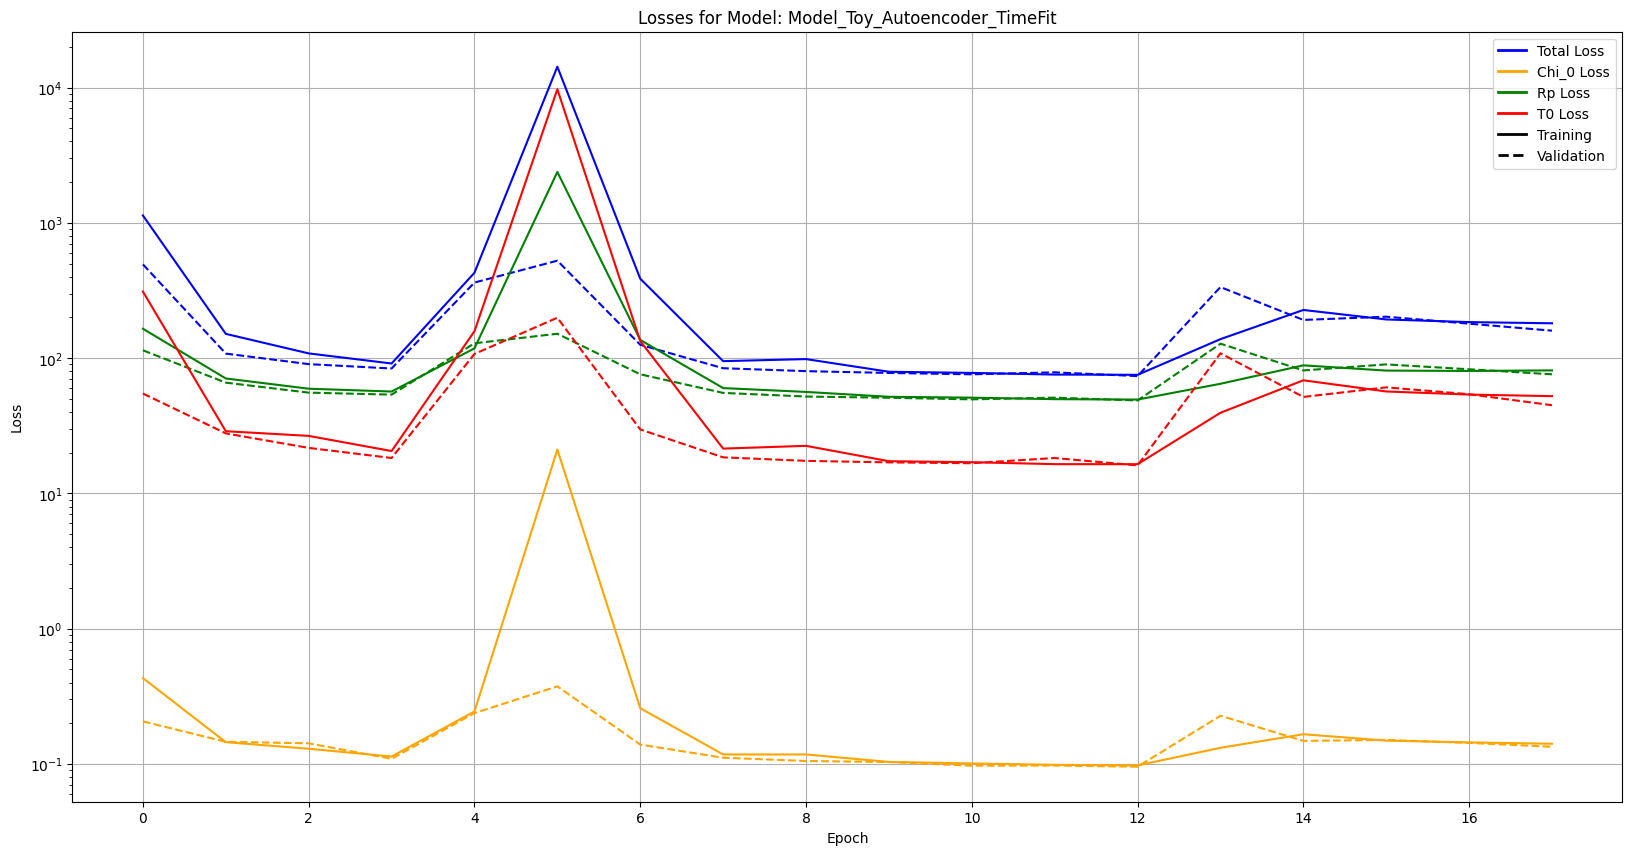

In [606]:
# Loss Plot
from matplotlib.lines import Line2D
Model_Names = [model.Name]
Trackers = [tracker]
for Model_Name,Tracker in zip(Model_Names,Trackers):
    EpochLosses    = Tracker.EpochLoss
    EpochValLosses = Tracker.EpochValLoss
    Keys = list(EpochLosses.keys())
    Nepochs = len(EpochLosses[Keys[0]])

    ax = plt.figure(figsize=(20, 10)).gca()

    # Define colors
    colors = ['blue', 'orange', 'green', 'red','cyan','purple','magenta','yellow']


    custom_lines = []
    custom_keys  = []
    for i in range(len(Keys)):
        plt.plot(EpochLosses[Keys[i]]   , color=colors[i], label=Keys[i] + ' - Training')
        plt.plot(EpochValLosses[Keys[i]], color=colors[i], label=Keys[i] + ' - Validation', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=colors[i], lw=2))
        custom_keys.append(Keys[i]+' Loss')

    custom_lines+= [Line2D([0], [0], color='black', lw=2),
                    Line2D([0], [0], color='black', lw=2, linestyle='dashed')]
    custom_keys += ['Training', 'Validation']


    ax.legend(custom_lines, custom_keys)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) # integer ticks
    ax.set_title('Losses for Model: ' + Model_Name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_yscale('log')
    ax.grid()

tensor([[  1.8876,  30.2352,  48.7472],
        [  0.8006,  21.4850,  63.5121],
        [  1.2558,  24.2125, 107.8144],
        [  1.4395,  42.3081,  44.2734],
        [  3.0453,  23.6897,  -2.7167],
        [  2.4179,  37.6402, -33.9878],
        [  0.2872,  23.8844,  27.4649],
        [  0.1530,  43.8513,  -5.9730],
        [  1.2707,  15.8660, -38.1231],
        [  2.7186,  45.8792, -10.3163],
        [  1.2254,  16.6444,  41.7487],
        [  0.8549,  12.7099, -22.0455],
        [  1.6088,   9.0380,  43.5952],
        [  0.9411,  44.3281, -35.6665],
        [  0.2747,  29.9909,  95.3095],
        [  1.4702,   9.4325, 148.5581]])


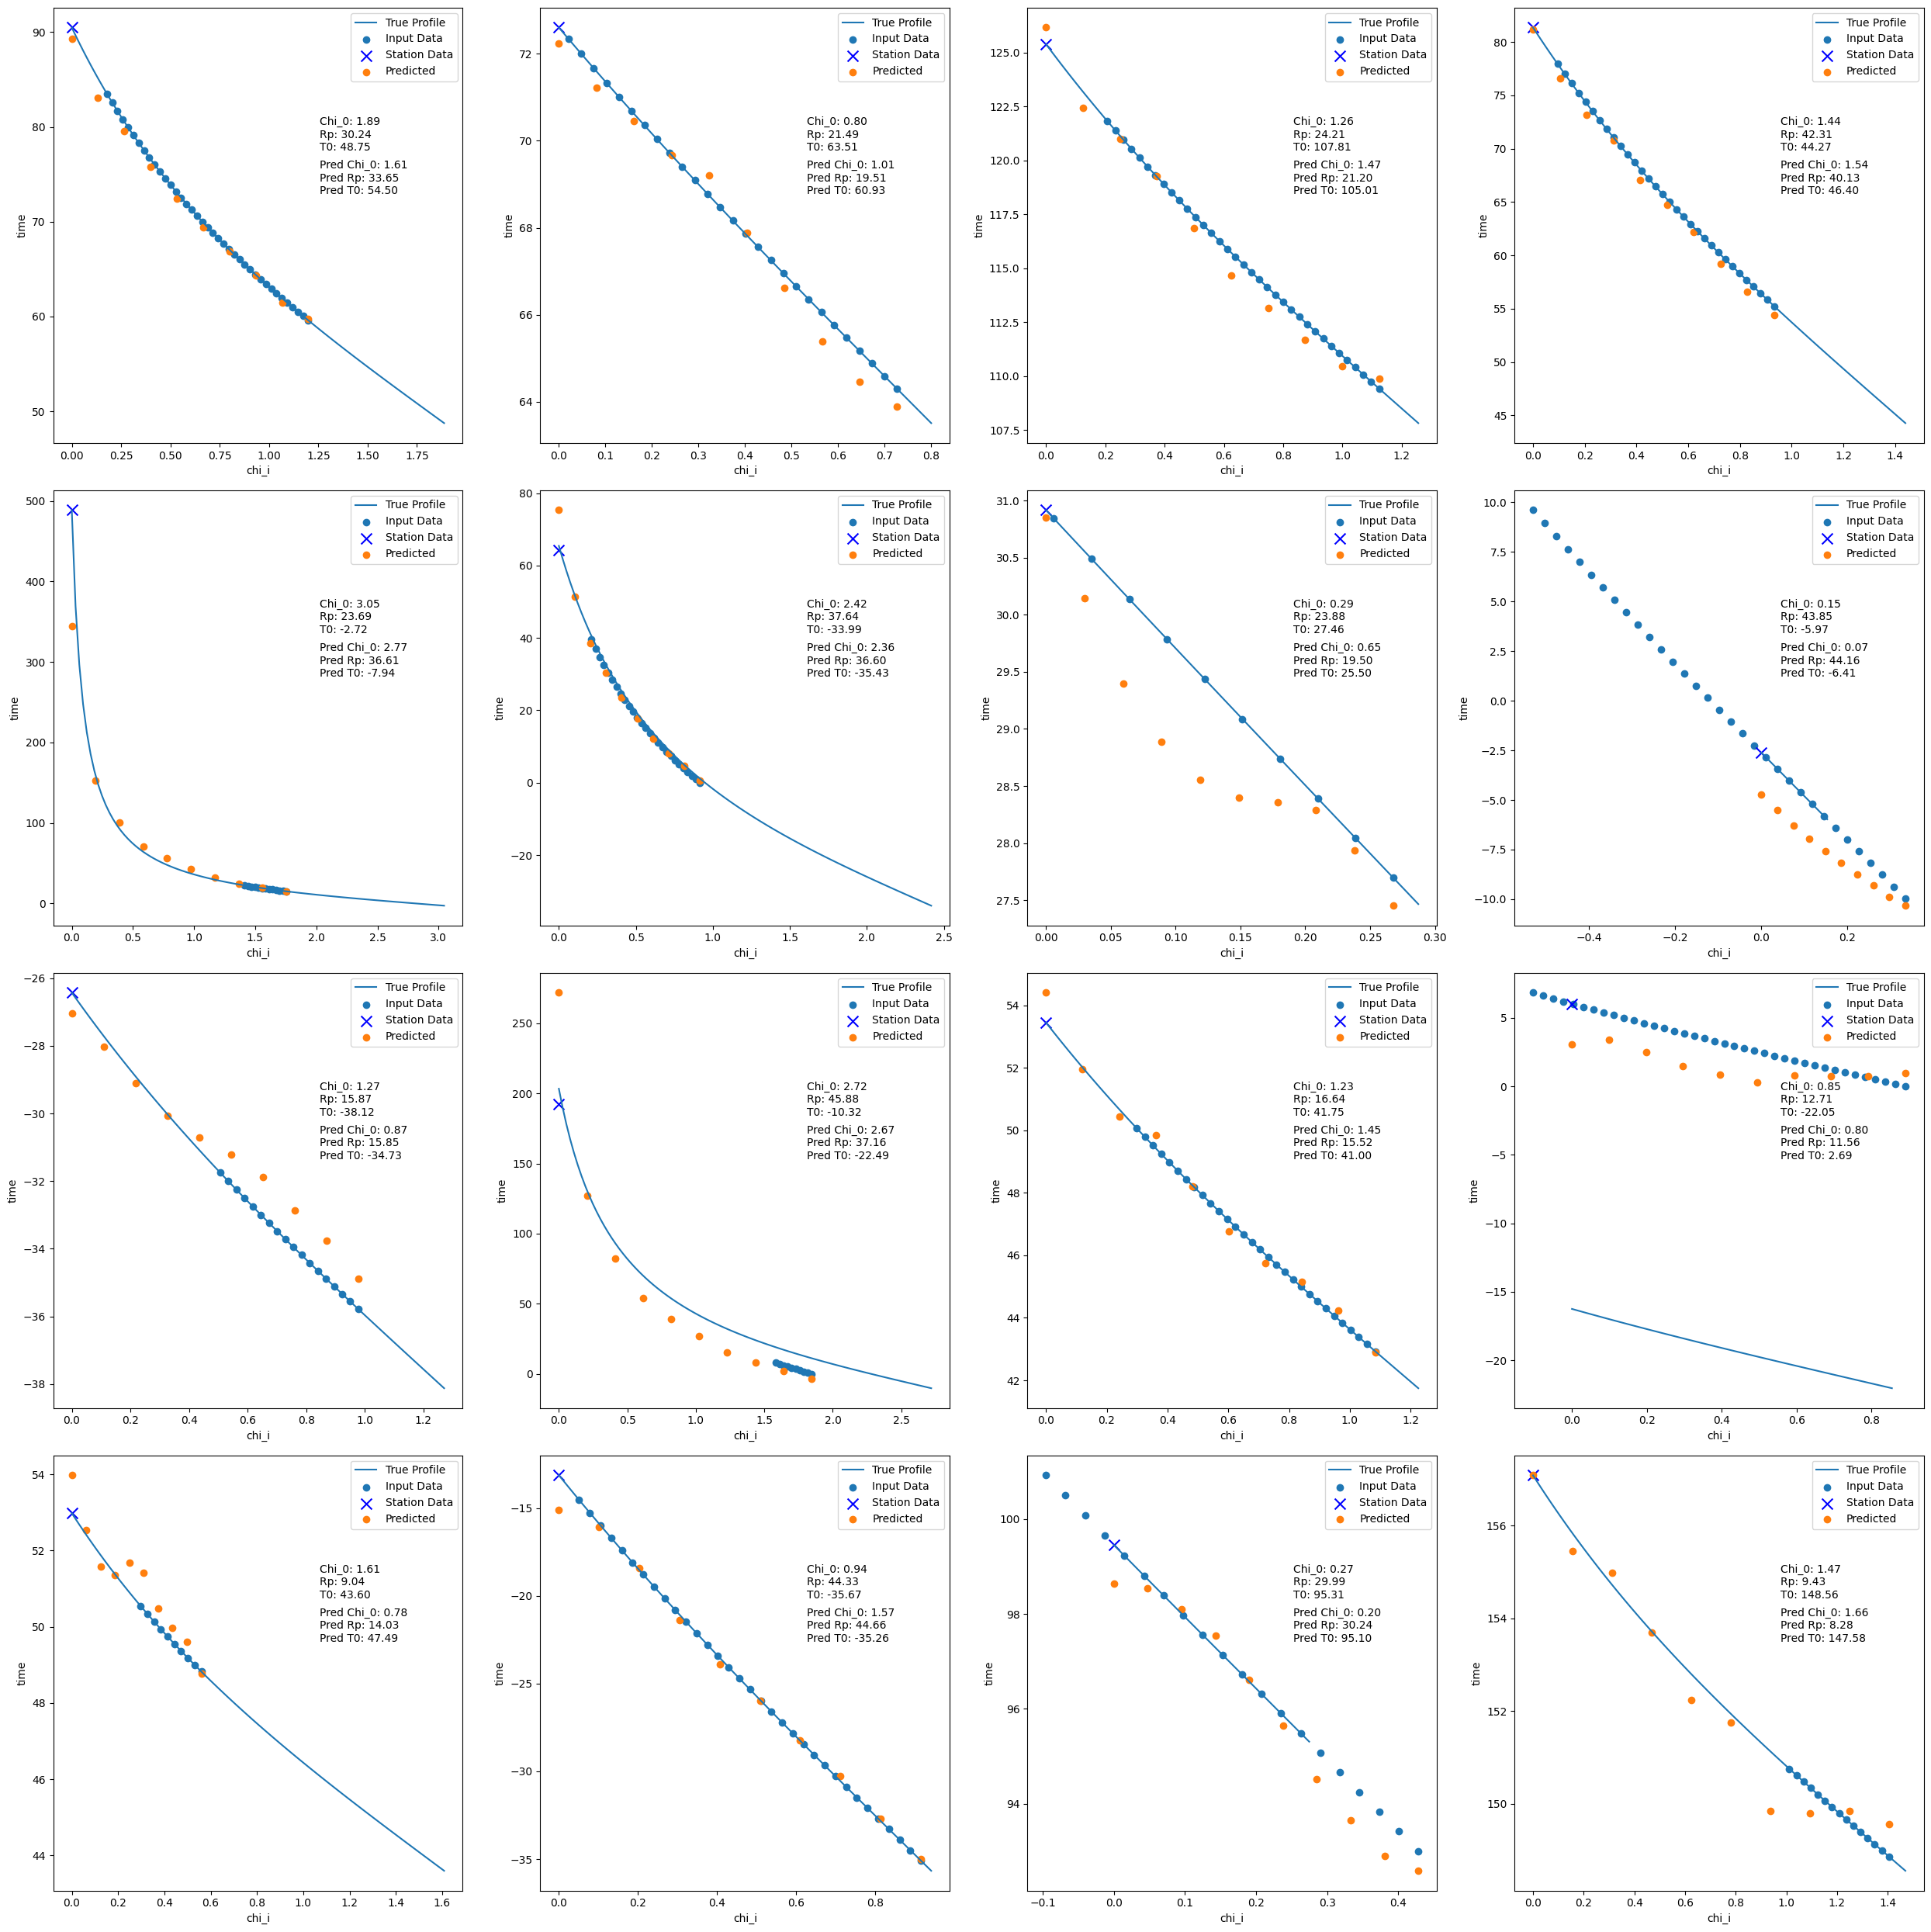

In [615]:
Dataset.State = 'Test'
Dataset.BatchSize = 16

model.eval()
with torch.no_grad():

    for _, BatchMain, BatchAux, BatchTruth, _ in Dataset:
        # print(BatchMain)
        # print(BatchAux)
        print(BatchTruth)
        break

    Model_Out = model(BatchMain,BatchAux)

    fig,ax = plt.subplots(4,4,figsize=(25,25))
    for fig_i in range(4):
        for fig_j in range(4):
            batch_i = fig_i*4 + fig_j
        


            This_Chi_0 = BatchTruth[batch_i,0]
            This_Rp    = BatchTruth[batch_i,1]
            This_T0    = BatchTruth[batch_i,2]

            plot_chi_i = torch.linspace(0,This_Chi_0,100)
            plot_time  = TimeFitEq_Toy(plot_chi_i,This_Chi_0,This_Rp,This_T0)

            ax[fig_i,fig_j].plot(plot_chi_i,plot_time,label='True Profile')
            ax[fig_i,fig_j].scatter(BatchMain[batch_i]['chi_i'],BatchMain[batch_i]['time'],label='Input Data')
            ax[fig_i,fig_j].scatter(BatchMain[batch_i]['station_chi_i'],BatchMain[batch_i]['station_time'],label='Station Data',color='blue',marker='x',s=100)

            pred_chi_i = Model_Out['test_chi_is'][batch_i].cpu()
            pred_time  = Model_Out['time_profile'][batch_i,:,1].cpu()

            ax[fig_i,fig_j].scatter(pred_chi_i,pred_time,label='Predicted')
            ax[fig_i,fig_j].set_xlabel('chi_i')
            ax[fig_i,fig_j].set_ylabel('time')
            ax[fig_i,fig_j].legend()
            
            Prams_Text = f"Chi_0: {This_Chi_0:.2f}\nRp: {This_Rp:.2f}\nT0: {This_T0:.2f}"
            ax[fig_i,fig_j].text(0.65,0.75,Prams_Text,transform=ax[fig_i,fig_j].transAxes,verticalalignment='top')

            GeomPred = Model_Out['geometry'][batch_i].cpu()
            Pred_Chi_0 = GeomPred[0]
            Pred_Rp    = GeomPred[1]
            Pred_T0    = GeomPred[2]
            Pred_Text = f"Pred Chi_0: {Pred_Chi_0:.2f}\nPred Rp: {Pred_Rp:.2f}\nPred T0: {Pred_T0:.2f}"
            ax[fig_i,fig_j].text(0.65,0.65,Pred_Text,transform=ax[fig_i,fig_j].transAxes,verticalalignment='top')
    plt.tight_layout()


tensor([[  1.7675,   6.1259, 108.6437]])
tensor([[  2.6853,  26.1056, 108.1795]])
tensor([[ 2.5716, 23.8346, 23.6669]])
tensor([[ 1.0286, 38.1792, 84.6386]])
tensor([[ 2.5167, 10.6734, 10.4125]])


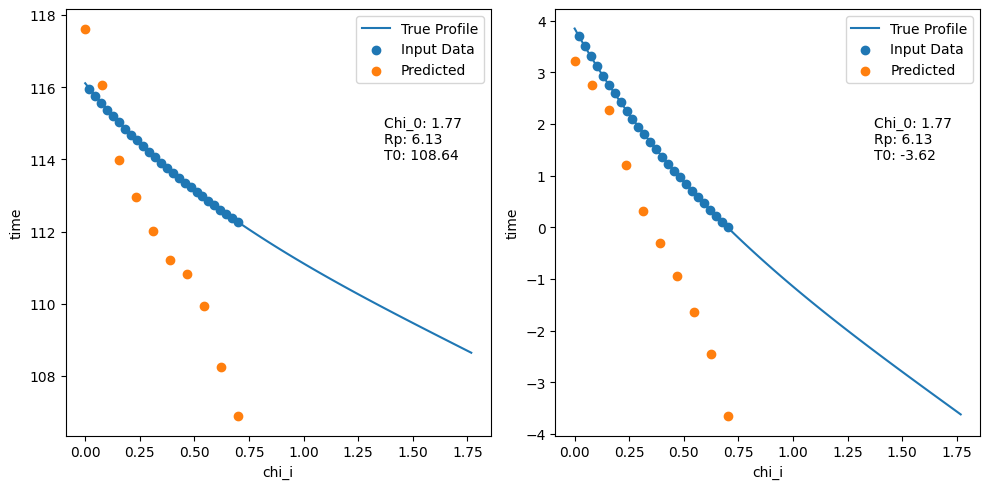

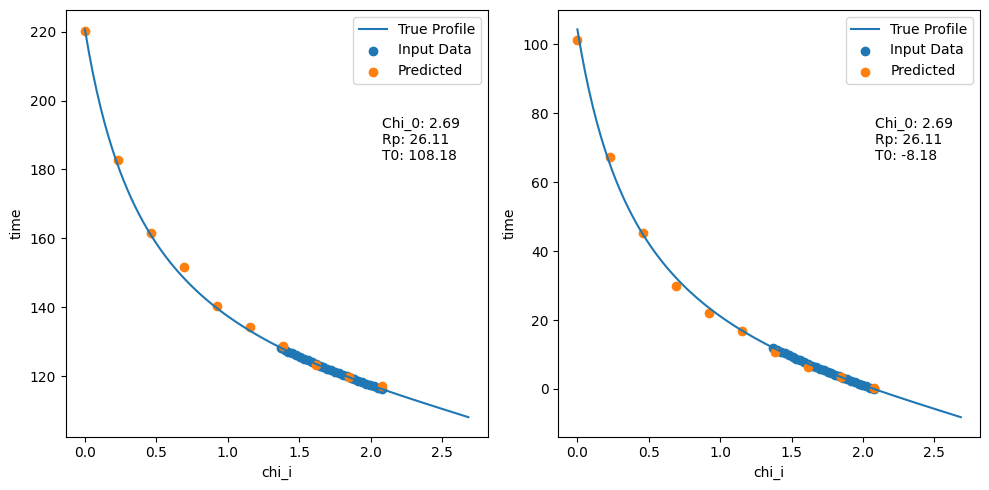

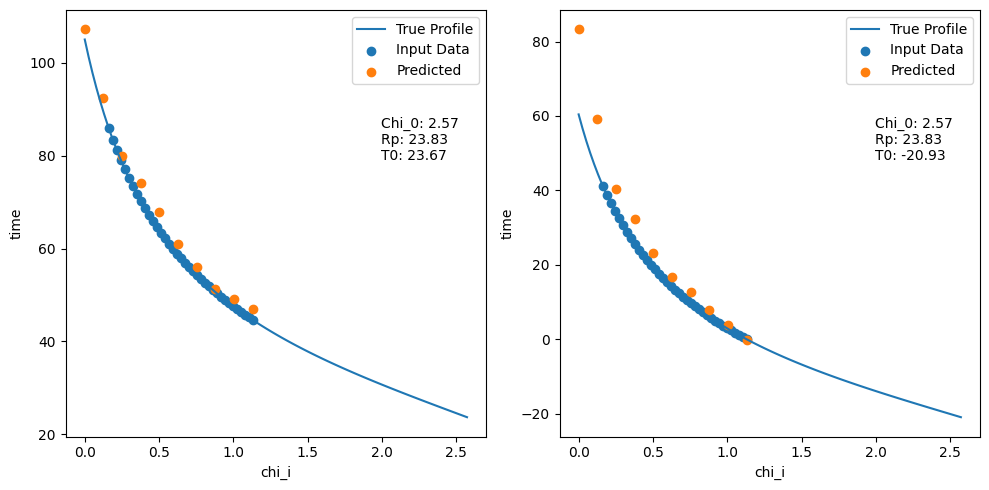

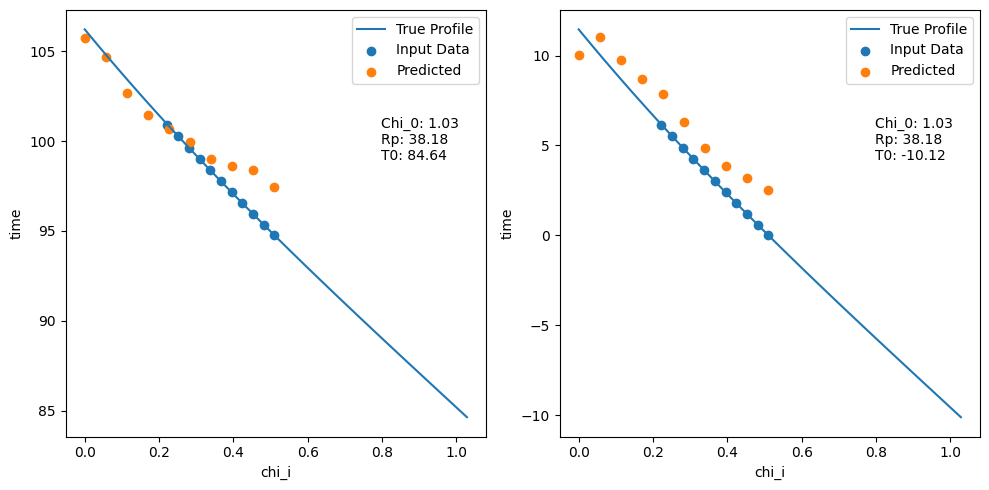

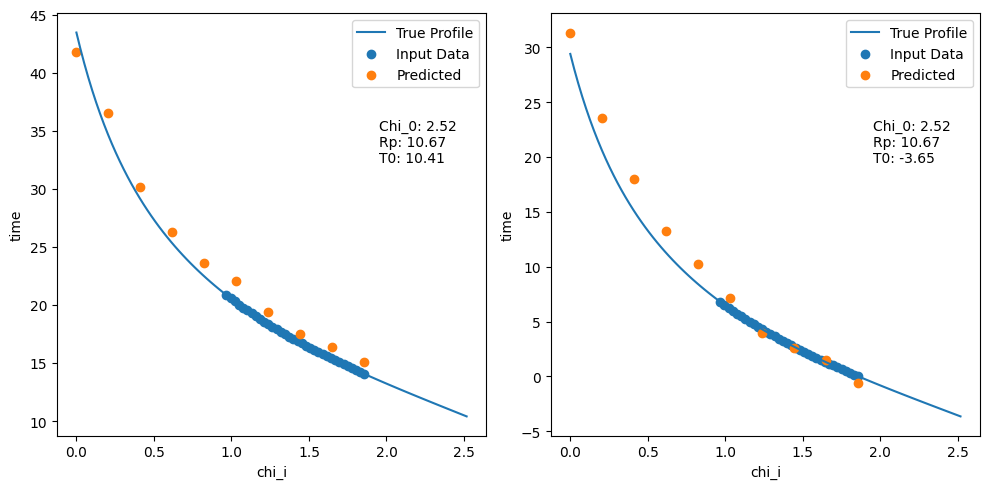

In [616]:
from copy import deepcopy


Dataset.State = 'Test'
Dataset.BatchSize = 1

model.eval()
for _ in range(5):
    with torch.no_grad():

        for _, BatchMain, BatchAux, BatchTruth, _ in Dataset:
            # print(BatchMain)
            # print(BatchAux)
            print(BatchTruth)
            break
        
        BatchMainNorm = deepcopy(BatchMain[0])
        
        Norm_Time_Shift = torch.min(BatchMainNorm['time'])
        BatchMainNorm['time'] = BatchMainNorm['time'] - Norm_Time_Shift
        BatchMainNorm['station_time'] = BatchMainNorm['station_time'] - Norm_Time_Shift
        
        BatchTruthNorm = deepcopy(BatchTruth[0])
        BatchTruthNorm[2] = BatchTruthNorm[2] - Norm_Time_Shift
        
        BatchMain.append(BatchMainNorm)
        BatchAux = torch.cat([BatchAux,BatchAux[0].unsqueeze(0)],dim = 0)
        BatchTruth = torch.cat([BatchTruth,BatchTruthNorm.unsqueeze(0)],dim = 0)
        

        Model_Out = model(BatchMain,BatchAux)

        fig,ax = plt.subplots(1,2,figsize=(10,5))
        for fig_i in range(2):
            
            batch_i = fig_i
        
            This_Chi_0 = BatchTruth[batch_i,0]
            This_Rp    = BatchTruth[batch_i,1]
            This_T0    = BatchTruth[batch_i,2]

            plot_chi_i = torch.linspace(0,This_Chi_0,100)
            plot_time  = TimeFitEq_Toy(plot_chi_i,This_Chi_0,This_Rp,This_T0)

            ax[fig_i].plot(plot_chi_i,plot_time,label='True Profile')
            ax[fig_i].scatter(BatchMain[batch_i]['chi_i'],BatchMain[batch_i]['time'],label='Input Data')

            pred_chi_i = Model_Out['test_chi_is'][batch_i].cpu()
            pred_time  = Model_Out['time_profile'][batch_i,:,1].cpu()

            ax[fig_i].scatter(pred_chi_i,pred_time,label='Predicted')
            ax[fig_i].set_xlabel('chi_i')
            ax[fig_i].set_ylabel('time')
            ax[fig_i].legend()
            
            Prams_Text = f"Chi_0: {This_Chi_0:.2f}\nRp: {This_Rp:.2f}\nT0: {This_T0:.2f}"
            ax[fig_i].text(0.75,0.75,Prams_Text,transform=ax[fig_i].transAxes,verticalalignment='top')

        plt.tight_layout()


[{'chi_i': tensor([0.8469, 0.8783, 0.9097, 0.9411, 0.9726, 1.0040]), 'time': tensor([25.6564, 24.9464, 24.2407, 23.5390, 22.8409, 22.1460]), 'station_chi_i': tensor([0]), 'station_time': tensor([48.2621])}]
tensor([[ 1.2658, 43.3890, 16.4323]])


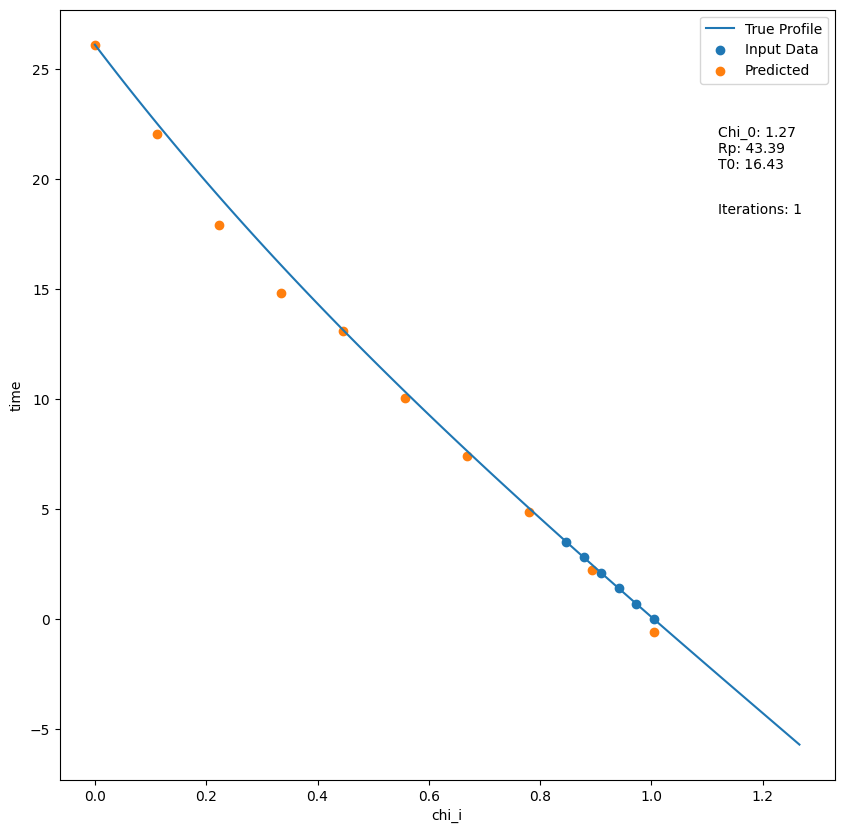

In [609]:
Dataset.State = 'Test'
Dataset.BatchSize = 1

model.eval()
with torch.no_grad():

    for _, BatchMain, BatchAux, BatchTruth, _ in Dataset:
        print(BatchMain)
        Norm_Time_Shift = torch.min(BatchMain[0]['time'])
        BatchMain[0]['time'] -= Norm_Time_Shift
        BatchMain[0]['station_time'] -= Norm_Time_Shift

        # print(BatchAux)
        print(BatchTruth)
        break

    Model_Out = model(BatchMain,BatchAux)

    This_Chi_0 = BatchTruth[0,0]
    This_Rp    = BatchTruth[0,1]
    This_T0    = BatchTruth[0,2]

    plot_chi_i = torch.linspace(0,This_Chi_0,100)
    plot_time  = TimeFitEq_Toy(plot_chi_i,This_Chi_0,This_Rp,This_T0) - Norm_Time_Shift

    plt.figure(figsize=(10,10))
    plt.plot(plot_chi_i,plot_time,label='True Profile')
    plt.scatter(BatchMain[0]['chi_i'],BatchMain[0]['time'],label='Input Data')

    pred_chi_i = Model_Out['test_chi_is'][0].cpu()
    pred_time  = Model_Out['time_profile'][0,:,1].cpu()
    Number_of_iterations = Model_Out['N_iter']
    # print(pred_chi_i)
    # print(pred_time)

    plt.scatter(pred_chi_i,pred_time,label='Predicted')
    plt.xlabel('chi_i')
    plt.ylabel('time')
    plt.legend()
    
    Prams_Text = f"Chi_0: {This_Chi_0:.2f}\nRp: {This_Rp:.2f}\nT0: {This_T0:.2f}"
    plt.text(0.85,0.85,Prams_Text,transform=plt.gca().transAxes,verticalalignment='top')
    plt.text(0.85,0.75,f'Iterations: {Number_of_iterations}',transform=plt.gca().transAxes,verticalalignment='top')

In [610]:
Dataset.State = 'Test'
Dataset.BatchSize = 1
All_N_Iters = []
All_Losses  = []

model.eval()
with torch.no_grad():

    for i,(_, BatchMain, BatchAux, BatchTruth, _) in enumerate(Dataset):
        if i % 100 == 0:
            print(f'Processing event {i} / {len(Dataset)}',end = '\r')
        Norm_Time_Shift = torch.min(BatchMain[0]['time'])
        BatchMain[0]['time'] -= Norm_Time_Shift
        BatchMain[0]['station_time'] -= Norm_Time_Shift

        Model_Out = model(BatchMain,BatchAux)
        N_iters = Model_Out['N_iter']
        All_N_Iters.append(N_iters)
        
        This_Loss = Loss_function(Model_Out, BatchTruth)['Profile_time'].item()
        All_Losses.append(This_Loss)

        # break
        if i == 10000:
            break
All_N_Iters = np.array(All_N_Iters)
All_Losses  = np.array(All_Losses)


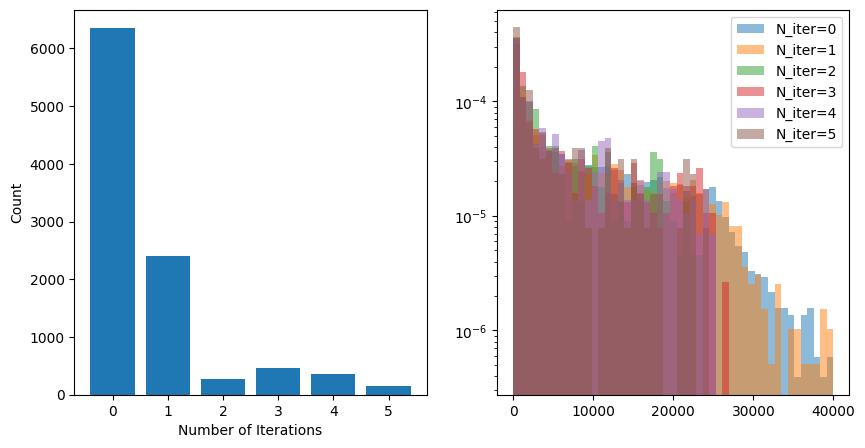

In [611]:
Unique_N_Iters, Unique_N_Iters_Counts = np.unique(All_N_Iters,return_counts=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.bar(Unique_N_Iters,Unique_N_Iters_Counts)
plt.xlabel('Number of Iterations')
plt.ylabel('Count')
plt.subplot(1,2,2)
for N_iter in Unique_N_Iters:
    plt.hist(All_Losses[All_N_Iters == N_iter], bins=np.linspace(All_Losses.min(), 40000, 50), alpha=0.5, label=f'N_iter={N_iter}',density=True)
plt.yscale('log')   
plt.legend()

In [618]:
# Compute the Test Set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
model.to(device)
torch.cuda.empty_cache()

Dataset.State      = 'Test'
Dataset.BatchSize  = len(Dataset)//256
# Dataset.BatchSize  = 64
Dataset.RandomIter = False

Truth   = []
Rec     = []
Pred    = []
Mains   = []
Auxs    = []


model.eval()
EvI = 0
with torch.no_grad():
    for EventIndex,BatchMains, BatchAux,BatchTruth,BatchRec in Dataset:
        Truth .append(BatchTruth)
        Rec   .append(BatchRec)
        Mains .append(deepcopy(BatchMains))
        Auxs  .append(BatchAux)

        
        Model_Out = model(BatchMains, BatchAux)
        Pred   .append(Model_Out['geometry'].cpu())
            
        EvI+=1
        # if EvI == 10: break

print()
Truth   = torch.cat(Truth  , dim=0)
Rec     = torch.cat(Rec    , dim=0)
Pred    = torch.cat(Pred   , dim=0)
Auxs    = torch.cat(Auxs   , dim=0)




Truth   = Truth.numpy()
Rec     = Rec  .numpy()
Pred    = Pred .numpy()
Auxs    = Auxs .numpy()

print(Truth.shape)
print(Pred.shape)



# chi_is = []
# charge = []
# time   = []

# station_chii = []
# station_time = []
# station_signal = []


# for Batch in Mains:
#     for Main in Batch:
#         chi_is.append(Main['chi_is'].numpy())
#         charge.append(Main['charge'].numpy())
#         time  .append(Main['time']  .numpy())

#         station_chii.append(Main['station_chii'].item())
#         station_time.append(Main['station_time'].item())
#         station_signal.append(Main['station_signal'].item())

# station_time = np.array(station_time)
# station_signal = np.array(station_signal)
# station_chii  = np.array(station_chii)

# print(f'Station Measurements lengths: {len(station_time)}, {len(station_signal)}, {len(station_chii)}')
# print(f'Total Mains split into showers = {len(chi_is)}')
        


(100001, 3)
(100001, 3)


In [620]:
# Combined Deviation Plots Function Definition
from matplotlib.colors import LinearSegmentedColormap

# Create a truncated version of the spring colormap (first 90%)
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = LinearSegmentedColormap.from_list(
        f'truncated_{cmap.name}', 
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Original spring colormap
spring = plt.get_cmap('inferno_r')

# Truncated colormap: first 90%
truncated_inferno = truncate_colormap(spring, 0.05, 1)

def CombinedDeviationPlots(TruthKeys,TruthUnits,Truth,Pred,Rec):
    plt.style.use('default')
    fig, ax = plt.subplots(len(TruthKeys),2, figsize=(20,9*len(TruthKeys)))
    print(f'Total Points before cuts {len(Truth)}')
    for i in range(len(TruthKeys)):
        X  = Truth[:, i] if TruthUnits[i] != 'rad' else Truth[:, i]/np.pi*180
        Yp = Pred[:, i] - Truth[:, i] if TruthUnits[i] != 'rad' else (Pred[:, i] - Truth[:, i])/np.pi*180
        Yr = Rec [:, i] - Truth[:, i] if TruthUnits[i] != 'rad' else (Rec [:, i] - Truth[:, i])/np.pi*180
        
        # Scaling Cuts
        if   TruthKeys[i] == 'SDPTheta': cut = (np.abs(Yp)>0)  #& (np.abs(Yp)<20)    & (np.abs(Yr)<20)
        elif TruthKeys[i] == 'SDPPhi'  : cut = (np.abs(Yp)>0)  #& (np.abs(Yp)<20)    & (np.abs(Yr)<20) #   & (np.abs(X)<50)
        elif TruthKeys[i] == 'Chi0'    : cut = (np.abs(Yp)<20)    & (np.abs(Yr)<20)
        elif TruthKeys[i] == 'Rp'      : cut = (np.abs(Yp)<5000)  & (np.abs(Yr)<5000)
        elif TruthKeys[i] == 'CEDist'  : cut = (np.abs(Yp)<5000)  & (np.abs(Yr)<5000)
        elif TruthKeys[i] == 'T0'      : cut = (np.abs(Yp)<10000) & (np.abs(Yr)<10000)
        elif TruthKeys[i] == 'Xmax'    : cut = (np.abs(Yp)<200)   & (np.abs(Yr)<200)  & (X>100)
        elif TruthKeys[i] == 'LogE'    : cut = (X>0)             # & (np.abs(Yp)<3000)    & (np.abs(Yr)<3000)
        elif TruthKeys[i] == 'z'       : cut = (X>0.4) 
        else: cut = (np.abs(Yp)>0)

        
        X = X[cut]
        Yp = Yp[cut]
        Yr = Yr[cut]

        # Secondary Y_lim cuts for scaling
        # Yp_STD = np.percentile(np.abs(Yp),68)
        # cut = (np.abs(Yp)<5*Yp_STD) & (np.abs(Yr)<5*Yp_STD)
        # X  = X [cut]
        # Yp = Yp[cut]
        # Yr = Yr[cut]
        print(f'{TruthKeys[i]} Total Points after cuts {len(X)}')
        # sns.scatterplot(x=X, y=Yp, ax=ax[i,0], s=5,color='orange')
        # sns.scatterplot(x=X, y=Yr, ax=ax[i,1], s=5,color='orange')

        sns.scatterplot(x=X, y=Yp, ax=ax[i,0], s=5,color=truncated_inferno(0))
        sns.scatterplot(x=X, y=Yr, ax=ax[i,1], s=5,color=truncated_inferno(0))


        sns.histplot(x=X, y=Yp, ax=ax[i,0], bins=100, pthresh=0.1,cmap = truncated_inferno,cbar = True)
        sns.histplot(x=X, y=Yr, ax=ax[i,1], bins=100, pthresh=0.1,cmap = truncated_inferno,cbar = True)
        if TruthUnits[i] != 'rad': 
            ax[i,0].set_ylabel(f'Model-Truth ({TruthUnits[i]})')
            ax[i,0].set_xlabel(f'Truth {TruthKeys[i]} ({TruthUnits[i]})')

            ax[i,1].set_ylabel(f'Reconstruction-Truth ({TruthUnits[i]})')
            ax[i,1].set_xlabel(f'Truth {TruthKeys[i]} ({TruthUnits[i]})')

            
        else:                      
            ax[i,0].set_ylabel(f'Model-Truth (degrees)')
            ax[i,0].set_xlabel(f'Truth {TruthKeys[i]} (degrees)')

            ax[i,1].set_ylabel(f'Reconstruction-Truth (degrees)')
            ax[i,1].set_xlabel(f'Truth {TruthKeys[i]} (degrees)')
        
        ax[i,0].set_title(f'{TruthKeys[i]} - Model')
        ax[i,1].set_title(f'{TruthKeys[i]} - Reconstruction')

        ax[i,0].set_xlim(min(X),max(X))
        ax[i,1].set_xlim(min(X),max(X))

        ax[i,0].grid()
        ax[i,1].grid()

        # ax[0,1].set_facecolor('lightgrey')
        # ax[1,1].set_facecolor('lightgrey')


        # 68th Percentile
        Percentile68_p = np.percentile(np.abs(Yp),68)
        Percentile68_r = np.percentile(np.abs(Yr),68)

        # ax[i,0].set_ylim(-Percentile68_p*5,Percentile68_p*5)
        # ax[i,1].set_ylim(-Percentile68_p*5,Percentile68_p*5)



        # Add as a texbox to top right of plot
        if TruthUnits[i]!= 'rad':
            ax[i,0].text(0.95, 0.95, f'$\\sigma$: {Percentile68_p:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.95, f'$\\sigma$: {Percentile68_r:.3} ({TruthUnits[i]})', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)

        else:
            ax[i,0].text(0.95, 0.95, f'$\\sigma$: {Percentile68_p:.3} (deg)', verticalalignment='top', horizontalalignment='right', transform=ax[i,0].transAxes, fontsize=15)
            ax[i,1].text(0.95, 0.95, f'$\\sigma$: {Percentile68_r:.3} (deg)', verticalalignment='top', horizontalalignment='right', transform=ax[i,1].transAxes, fontsize=15)



        ax[i,0].axhline(Percentile68_p, color='cyan', linestyle='--')
        ax[i,0].axhline(-Percentile68_p, color='cyan', linestyle='--')

        ax[i,1].axhline(Percentile68_r, color='cyan', linestyle='--')
        ax[i,1].axhline(-Percentile68_r, color='cyan', linestyle='--')
        
    return fig

Total Points before cuts 100001
Chi_0 Total Points after cuts 100001
Rp Total Points after cuts 100001
T0 Total Points after cuts 100001


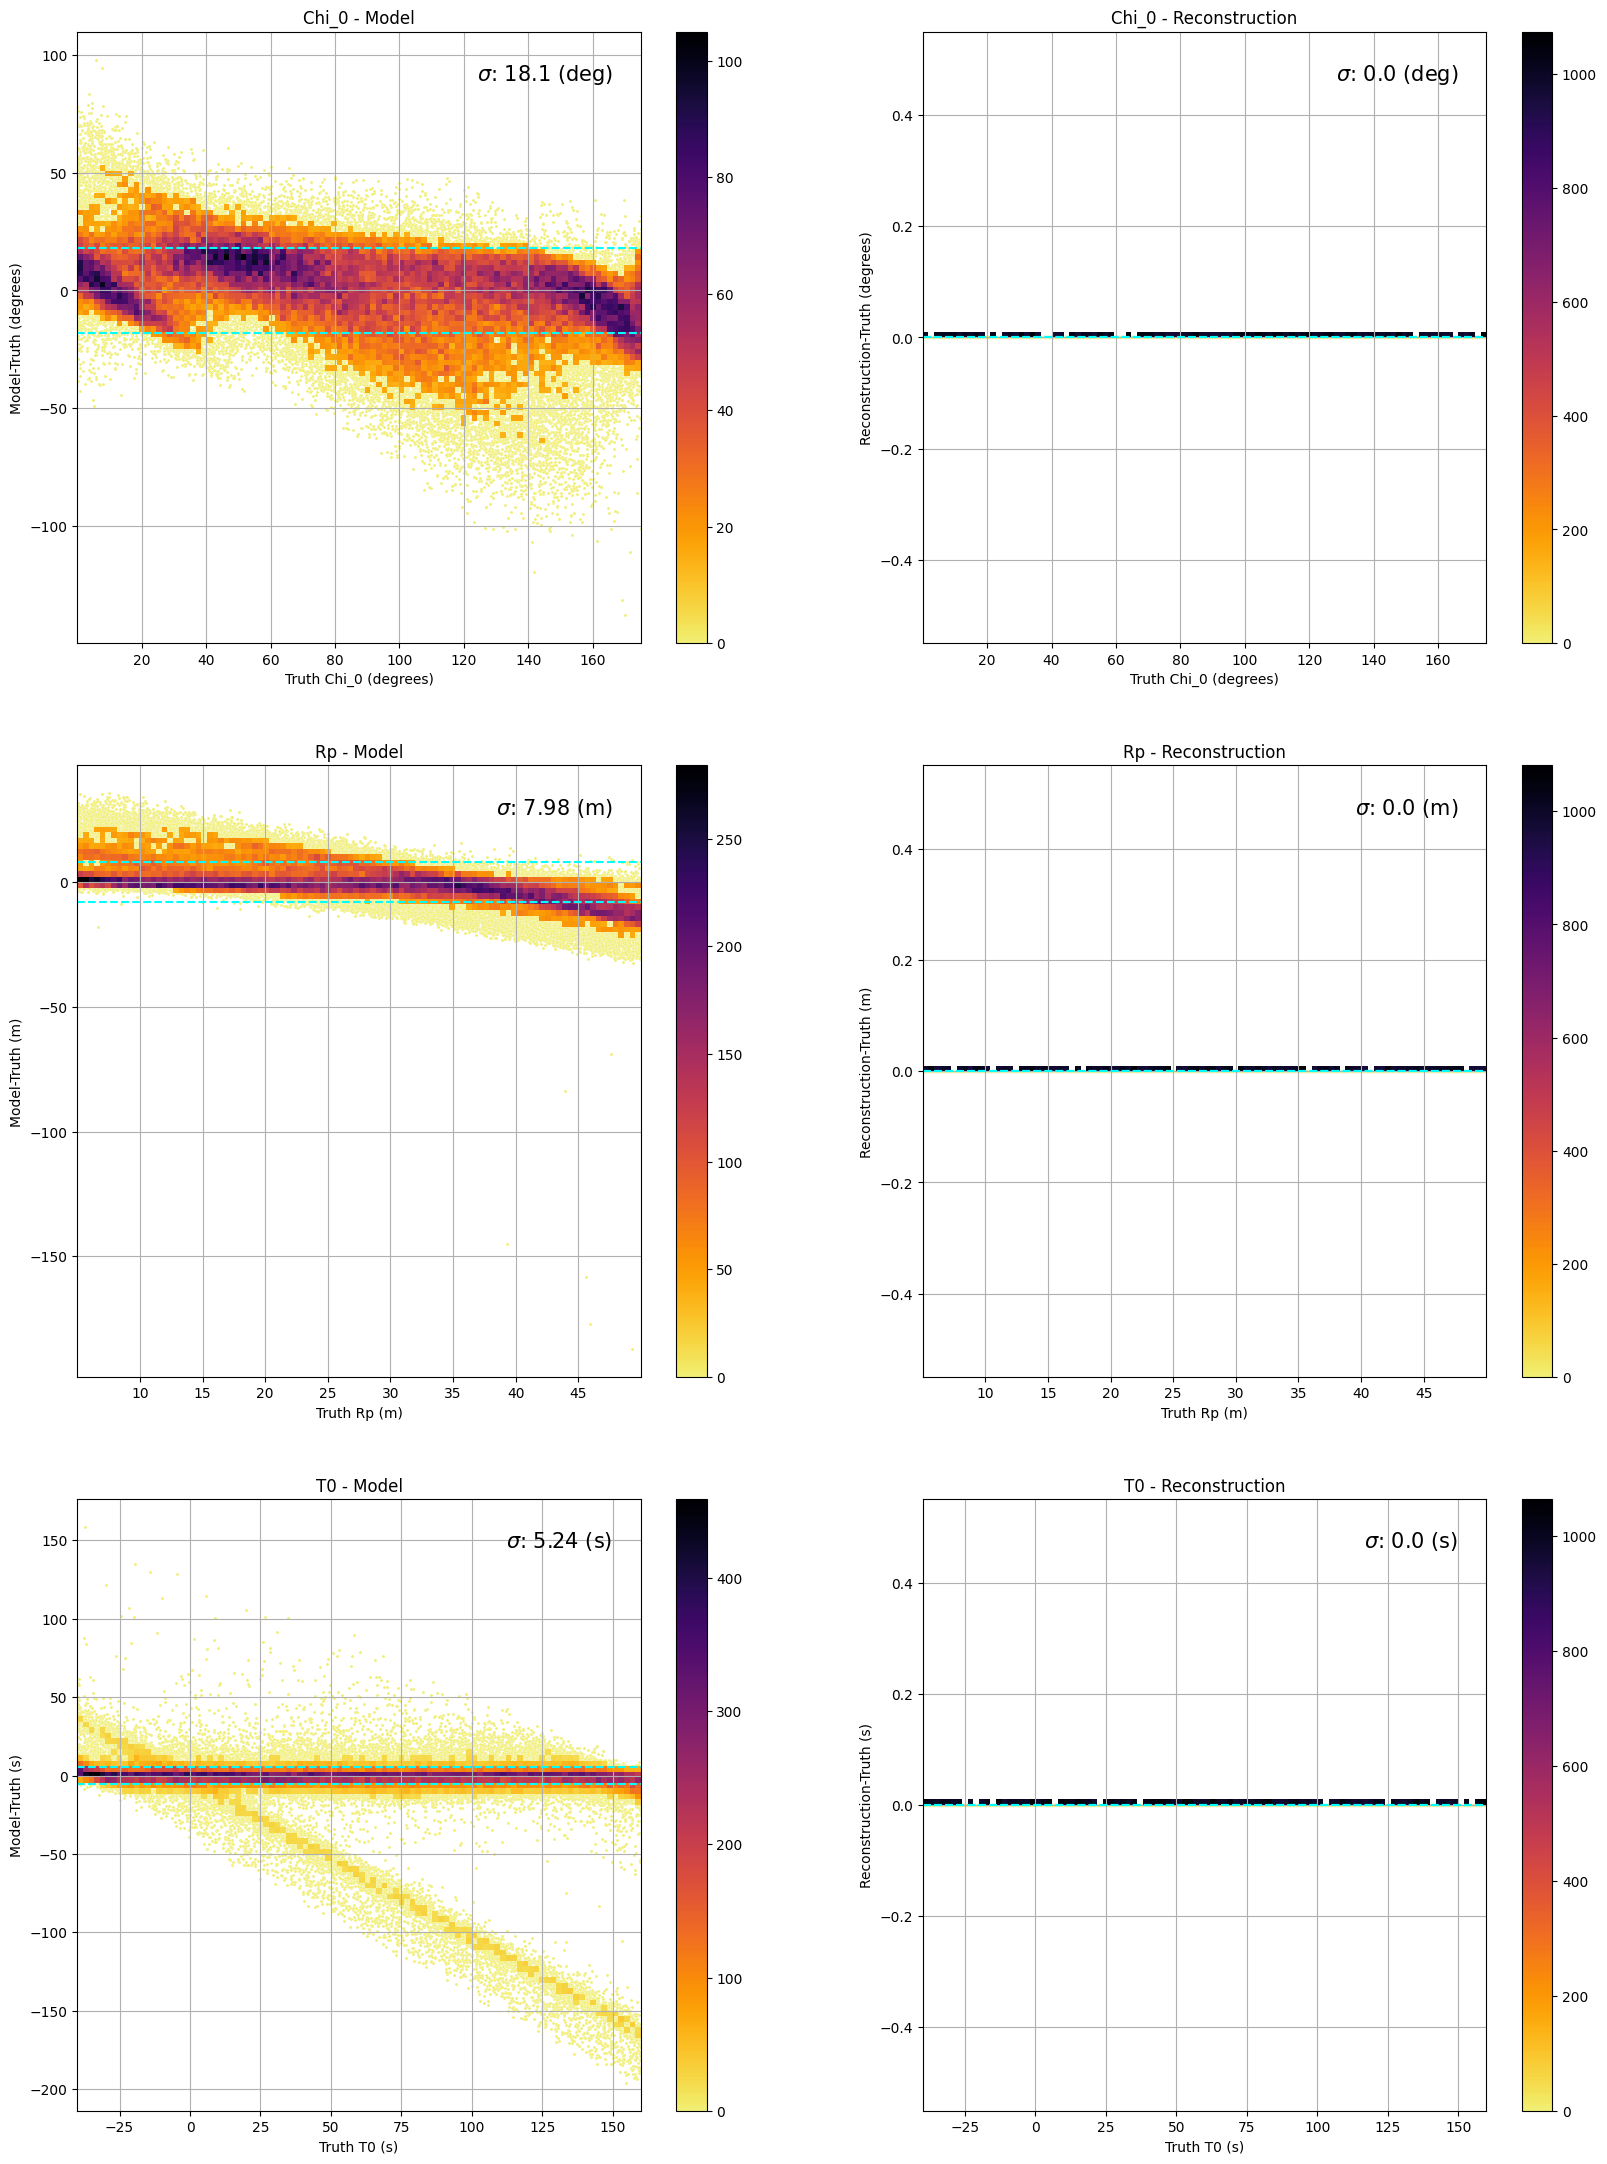

In [621]:
TruthKeys = Dataset.Truth_Keys
TruthUnits = Dataset.Truth_Units

fig = CombinedDeviationPlots(TruthKeys,TruthUnits,Truth,Pred,Rec)
